In [ ]:
pip install pandas numpy matplotlib seaborn textblob wordcloud

In [ ]:
import pandas as pd

In [ ]:
df = pd.read_csv('/content/chatgpt_reviews.csv')
df.head()
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 196727 entries, 0 to 196726
Data columns (total 4 columns):
 #   Column       Non-Null Count   Dtype 
---  ------       --------------   ----- 
 0   Review Id    196727 non-null  object
 1   Review       196721 non-null  object
 2   Ratings      196727 non-null  int64 
 3   Review Date  196727 non-null  object
dtypes: int64(1), object(3)
memory usage: 6.0+ MB


,Ratings
count,196727.000000
mean,4.503535
std,1.083004
min,1.000000
25%,5.000000
50%,5.000000
75%,5.000000
max,5.000000


In [ ]:
from textblob import TextBlob

df['polarity'] = df['review'].apply(lambda x: TextBlob(x).sentiment.polarity)
df['subjectivity'] = df['review'].apply(lambda x: TextBlob(x).sentiment.subjectivity)
df.columns = df.columns.str.lower().str.replace(" ", "_")

In [ ]:
def get_sentiment(p):
    if p > 0.05:
        return 'Positive'
    elif p < -0.05:
        return 'Negative'
    else:
        return 'Neutral'

df['sentiment'] = df['polarity'].apply(get_sentiment)

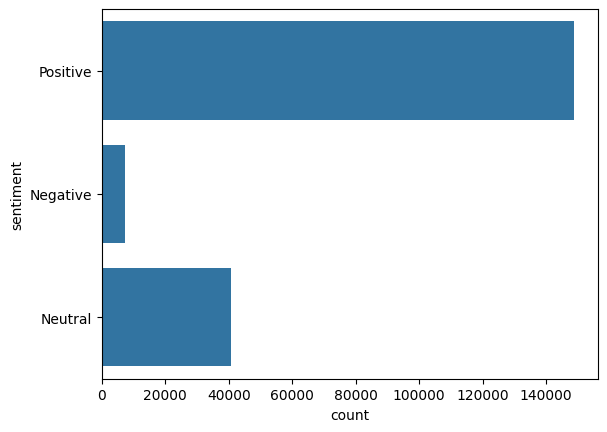

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(df['sentiment'])
plt.show()

In [ ]:
positive_df = df[df['sentiment'] == 'Positive']

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer

cv = CountVectorizer(stop_words='english', max_features=20)
word_count = cv.fit_transform(positive_df['review'])
words = cv.get_feature_names_out()

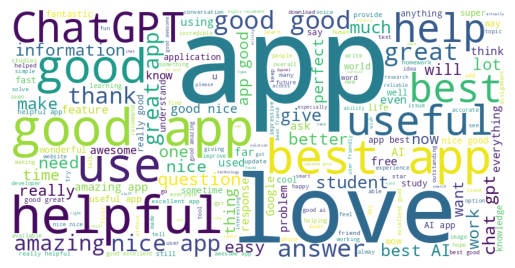

In [ ]:
from wordcloud import WordCloud

text = " ".join(positive_df['review'])
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text)

plt.imshow(wordcloud)
plt.axis('off')
plt.show()

<Axes: xlabel='polarity', ylabel='Count'>

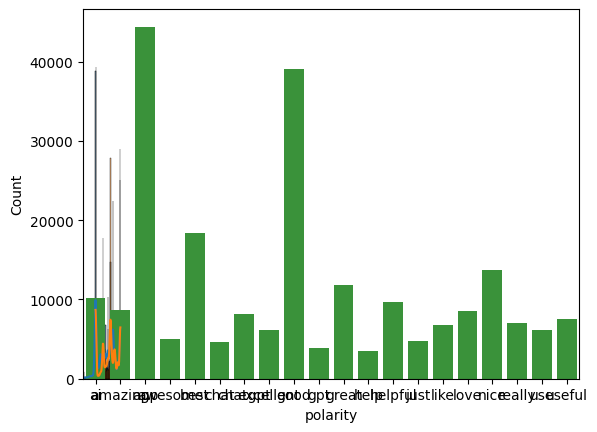

In [ ]:
sns.histplot(df['polarity'], kde=True)
sns.histplot(df['subjectivity'], kde=True)

sns.barplot(x=words, y=word_count.toarray().sum(axis=0))